# Phase 1: Advanced Regression Modeling

In this notebook, you will:
1. Load and explore the California Housing dataset
2. Preprocess features and engineer new ones
3. Build multiple regression models (Linear, Ridge, Lasso, ElasticNet, Polynomial)
4. Build tree-based models (Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM)
5. Evaluate and compare all models
6. Check for multicollinearity (VIF) and heteroskedasticity
7. Perform cross-validation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import your modules
import sys
sys.path.insert(0, '..')
from src.data_loader import load_housing_data, preprocess_features, split_data, create_feature_engineering
from src.regression import *


## 1. Data Loading & Exploration

In [2]:
# Load the dataset
df = load_housing_data()
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Basic statistics
df.head()
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


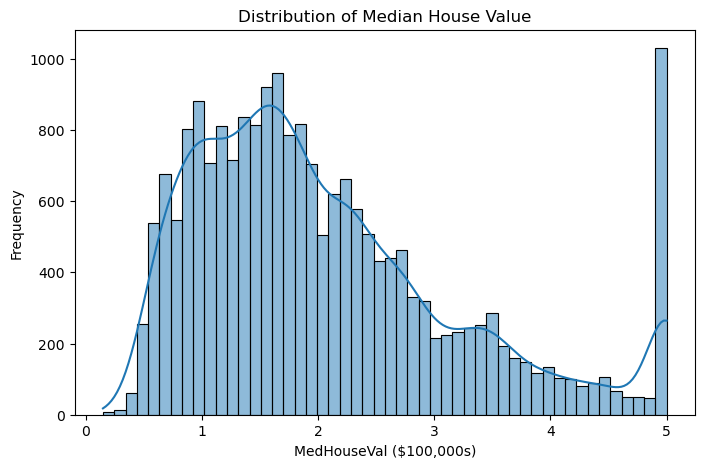

In [4]:
# TODO: Create visualizations
# - Distribution of target variable (MedHouseVal)
# - Correlation heatmap
# - Scatter plots of key features vs target

plt.figure(figsize=(8, 5))
sns.histplot(df['MedHouseVal'], bins=50, kde=True)
plt.title("Distribution of Median House Value")
plt.xlabel("MedHouseVal ($100,000s)")
plt.ylabel("Frequency")
plt.show()

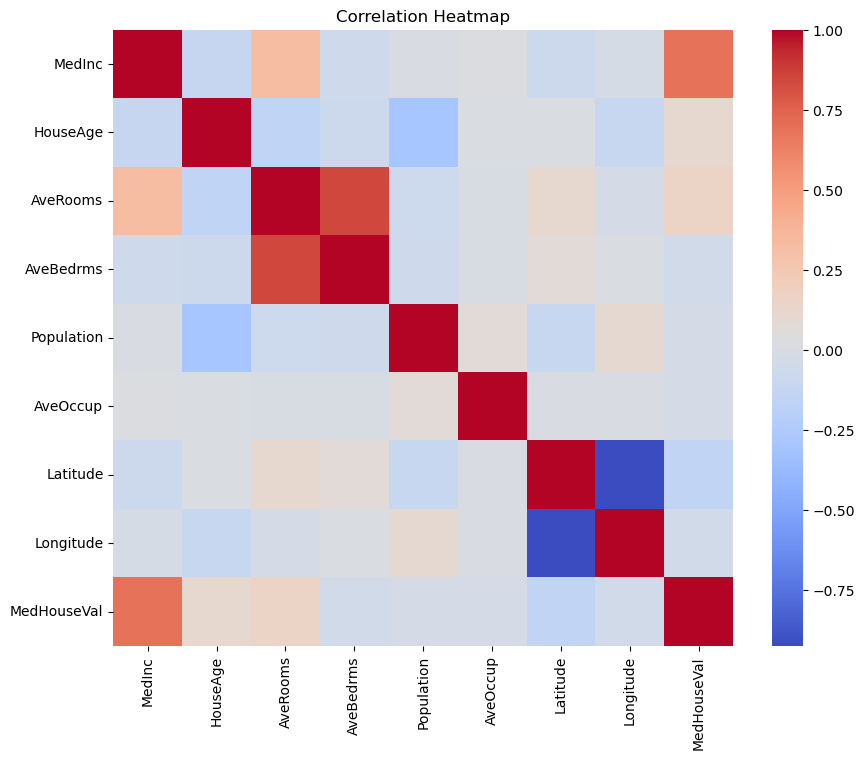

In [5]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

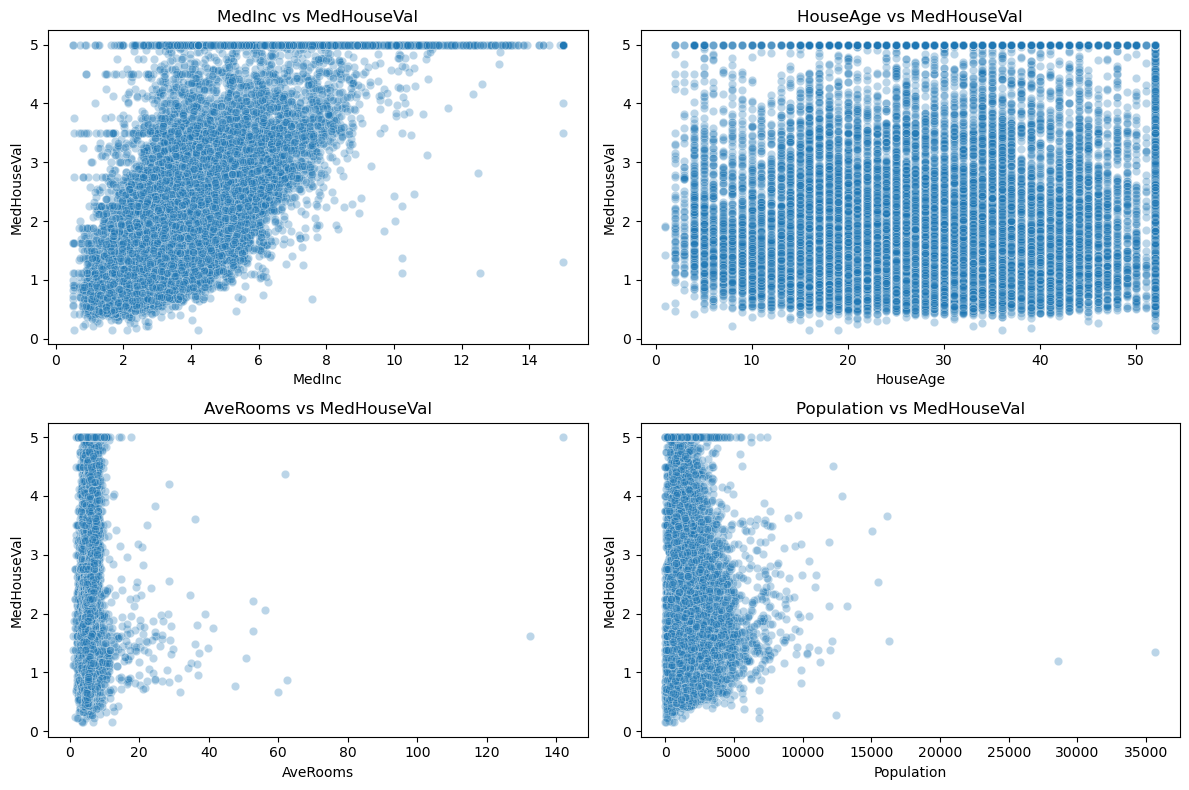

In [6]:
features = ['MedInc', 'HouseAge', 'AveRooms', 'Population']

plt.figure(figsize=(12, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(x=df[feature], y=df['MedHouseVal'], alpha=0.3)
    plt.title(f"{feature} vs MedHouseVal")

plt.tight_layout()
plt.show()

## 2. Feature Engineering & Preprocessing

In [7]:
# Engineer new features
df_eng = create_feature_engineering(df)
print(f"Original columns: {df.shape[1]}")
print(f"After engineering: {df_eng.shape[1]}")
print(f"New columns: {set(df_eng.columns) - set(df.columns)}")

Original columns: 9
After engineering: 12
New columns: {'rooms_per_household', 'bedrooms_ratio', 'population_density'}


In [8]:
# Preprocess and split
X_scaled, y, feature_names, scaler = preprocess_features(df_eng)
X_train, X_test, y_train, y_test = split_data(X_scaled, y)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (16512, 11), Test size: (4128, 11)


## 3. Linear Models

In [9]:
# TODO: Build and evaluate each linear model
# - Linear Regression
# - Ridge Regression (try multiple alphas)
# - Lasso Regression (try multiple alphas)
# - ElasticNet (try multiple alpha and l1_ratio combinations)
# - Polynomial Regression (try degree 2 and 3)

df = load_housing_data()

X, y, feature_names, scaler = preprocess_features(df)
X_train, X_test, y_train, y_test = split_data(X, y)

In [10]:
models = {}

# 1. Linear Regression
models["Linear"] = build_linear_regression(X_train, y_train)

# 2. Ridge (multiple alphas)
for alpha in [0.1, 1.0, 10.0]:
    name = f"Ridge_alpha_{alpha}"
    models[name] = build_ridge_regression(X_train, y_train, alpha=alpha)

# 3. Lasso (multiple alphas)
for alpha in [0.001, 0.01, 0.1]:
    name = f"Lasso_alpha_{alpha}"
    models[name] = build_lasso_regression(X_train, y_train, alpha=alpha)

    # 4. ElasticNet
for alpha in [0.01, 0.1]:
    for l1_ratio in [0.2, 0.5, 0.8]:
        name = f"ElasticNet_a{alpha}_l1{l1_ratio}"
        models[name] = build_elasticnet_regression(
            X_train, y_train,
            alpha=alpha,
            l1_ratio=l1_ratio
        )

# 5. Polynomial Regression
for degree in [2, 3]:
    model, poly = build_polynomial_regression(X_train, y_train, degree=degree)
    models[f"Poly_deg_{degree}"] = (model, poly)

In [11]:
results = {}

for name, model in models.items():
    
    if isinstance(model, tuple):
        # Polynomial case
        model_obj, poly = model
        X_test_poly = poly.transform(X_test)
        metrics = evaluate_model(model_obj, X_test_poly, y_test)
    else:
        metrics = evaluate_model(model, X_test, y_test)
    
    results[name] = metrics

results_df = pd.DataFrame(results).T
results_df.sort_values("rmse")

,mse,rmse,mae,r2
Poly_deg_2,0.464302,0.681397,0.467001,0.645682
Lasso_alpha_0.01,0.547933,0.740225,0.535523,0.581861
ElasticNet_a0.01_l10.8,0.548461,0.740582,0.534909,0.581458
ElasticNet_a0.01_l10.5,0.549585,0.741340,0.534180,0.580601
ElasticNet_a0.01_l10.2,0.551011,0.742301,0.533642,0.579512
Lasso_alpha_0.001,0.554406,0.744585,0.533151,0.576921
Ridge_alpha_10.0,0.555499,0.745318,0.533141,0.576087
Ridge_alpha_1.0,0.555851,0.745554,0.533193,0.575819
Ridge_alpha_0.1,0.555888,0.745579,0.533199,0.575791
Linear,0.555892,0.745581,0.533200,0.575788


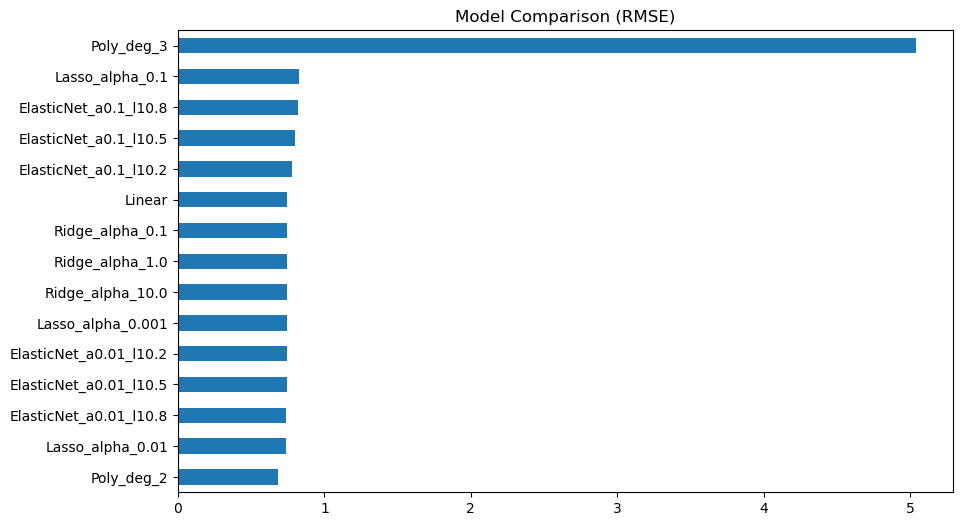

In [12]:
import matplotlib.pyplot as plt

results_df.sort_values("rmse")["rmse"].plot(kind="barh", figsize=(10, 6))
plt.title("Model Comparison (RMSE)")
plt.show()

## 4. Tree-Based Models

In [14]:

# 
#  TODO: Build and evaluate tree-based models
# - Decision Tree
# - Random Forest
# - Gradient Boosting
# - XGBoost
# - LightGBM
# Tree-based models

tree_models = {}
# 1. Decision Tree
tree_models["DecisionTree"] = build_decision_tree(
    X_train, y_train, max_depth=10
)

# 2. Random Forest
tree_models["RandomForest"] = build_random_forest(
    X_train, y_train,
    n_estimators=100,
    max_depth=None
)

# 3. Gradient Boosting
tree_models["GradientBoosting"] = build_gradient_boosting(
    X_train, y_train,
    n_estimators=100,
    learning_rate=0.1
)

# 4. XGBoost
try:
    tree_models["XGBoost"] = build_xgboost(
        X_train, y_train,
        n_estimators=100,
        learning_rate=0.1
    )
except Exception as e:
    print(f"XGBoost skipped: {e}")

# 5. LightGBM
try:
    tree_models["LightGBM"] = build_lightgbm(
        X_train, y_train,
        n_estimators=100,
        learning_rate=0.1
    )
except Exception as e:
    print(f"LightGBM skipped: {e}")

# Evaluate all tree models
tree_results = compare_models(tree_models, X_test, y_test)

tree_results

XGBoost skipped: No module named 'xgboost'
LightGBM skipped: No module named 'lightgbm'


,mse,rmse,mae,r2
DecisionTree,0.415095,0.644279,0.433097,0.683233
RandomForest,0.255498,0.505468,0.327613,0.805024
GradientBoosting,0.293999,0.542217,0.371650,0.775643


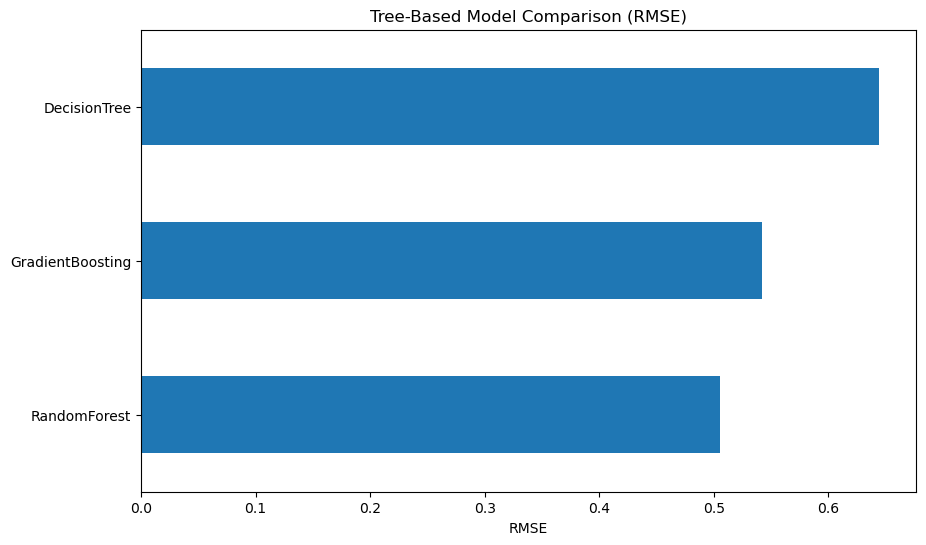

In [15]:
import matplotlib.pyplot as plt

tree_results.sort_values("rmse")["rmse"].plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Tree-Based Model Comparison (RMSE)")
plt.xlabel("RMSE")
plt.show()

## 5. Model Comparison

In [16]:
# TODO: Use compare_models() to create a comparison table
# TODO: Visualize model performance (bar chart of R², RMSE)

models       # from linear models
tree_models   # from tree-based models
all_models = {}

all_models.update(models)
all_models.update(tree_models)
results_df = compare_models(all_models, X_test, y_test)

# Sort by RMSE (lower is better)
results_df = results_df.sort_values("rmse")

results_df

,mse,rmse,mae,r2
RandomForest,0.255498,0.505468,0.327613,0.805024
GradientBoosting,0.293999,0.542217,0.371650,0.775643
DecisionTree,0.415095,0.644279,0.433097,0.683233
Poly_deg_2,0.464302,0.681397,0.467001,0.645682
Lasso_alpha_0.01,0.547933,0.740225,0.535523,0.581861
ElasticNet_a0.01_l10.8,0.548461,0.740582,0.534909,0.581458
ElasticNet_a0.01_l10.5,0.549585,0.741340,0.534180,0.580601
ElasticNet_a0.01_l10.2,0.551011,0.742301,0.533642,0.579512
Lasso_alpha_0.001,0.554406,0.744585,0.533151,0.576921
Ridge_alpha_10.0,0.555499,0.745318,0.533141,0.576087


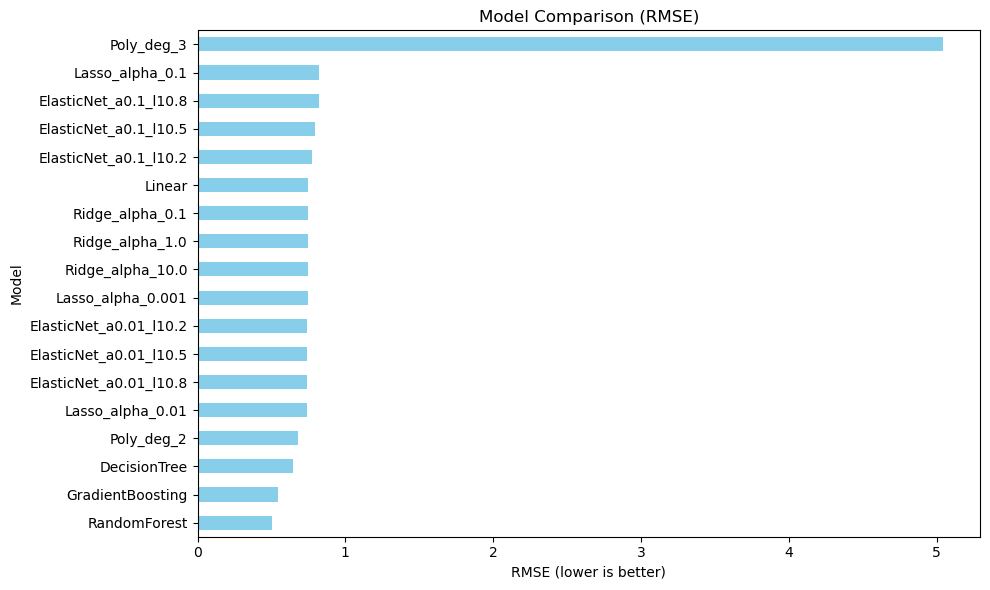

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

results_df["rmse"].plot(kind="barh", color="skyblue")

plt.title("Model Comparison (RMSE)")
plt.xlabel("RMSE (lower is better)")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

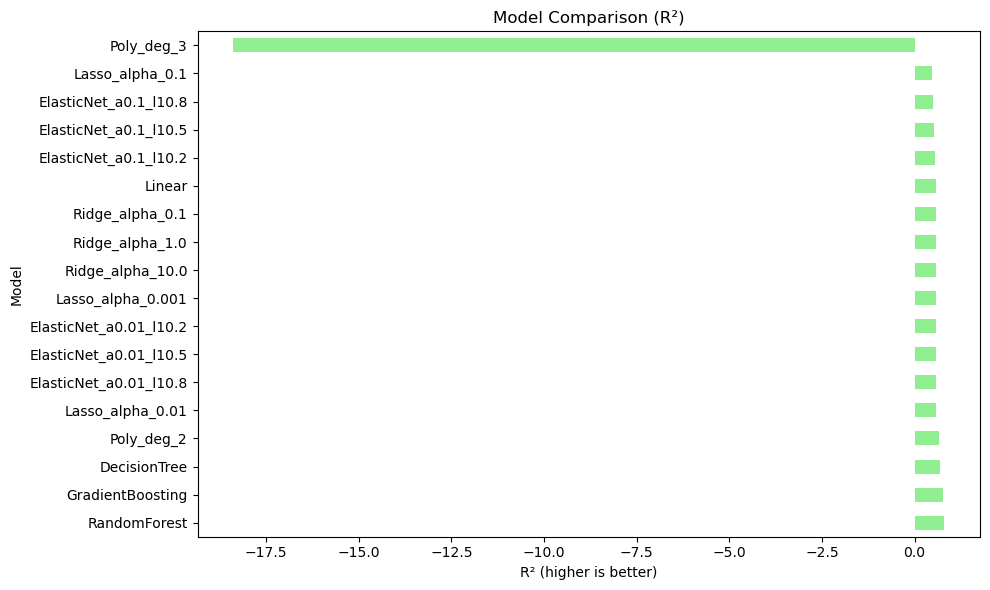

In [18]:
plt.figure(figsize=(10, 6))

results_df["r2"].plot(kind="barh", color="lightgreen")

plt.title("Model Comparison (R²)")
plt.xlabel("R² (higher is better)")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

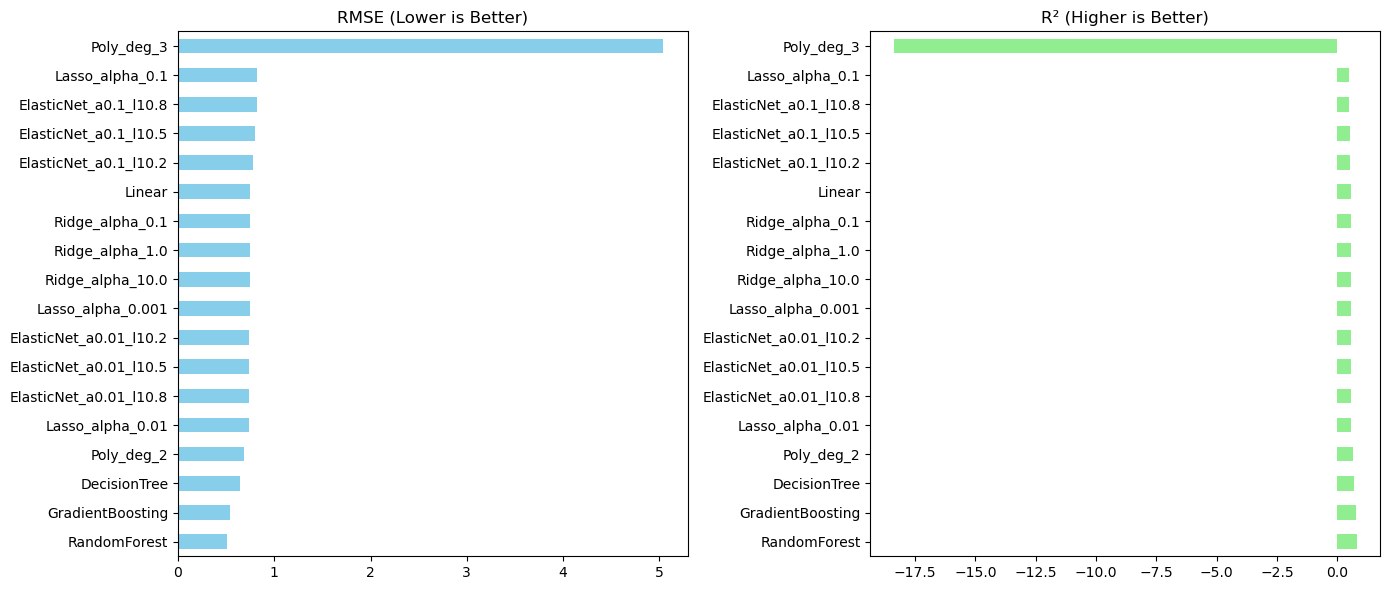

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# RMSE
results_df["rmse"].plot(kind="barh", ax=axes[0], color="skyblue")
axes[0].set_title("RMSE (Lower is Better)")

# R²
results_df["r2"].plot(kind="barh", ax=axes[1], color="lightgreen")
axes[1].set_title("R² (Higher is Better)")

plt.tight_layout()
plt.show()

## 6. Regression Diagnostics

### Multicollinearity (VIF Analysis)

In [20]:
# TODO: Compute VIF for each feature using statsmodels
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# Identify features with VIF > 10 (high multicollinearity)

from statsmodels.stats.outliers_influence import variance_inflation_factor
def compute_vif(X):
     # Ensure input is DataFrame
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)

    # Add constant (important for VIF)
    X = X.copy()
    X["Intercept"] = 1

    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns

    vif_data["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    # Remove intercept row
    vif_data = vif_data[vif_data["Feature"] != "Intercept"]

    return vif_data

### Heteroskedasticity Testing

In [21]:
# TODO: Check for heteroskedasticity
# - Plot residuals vs fitted values
# - Breusch-Pagan test (statsmodels)
# - Apply log transformation to target if needed
def plot_residuals(model, X_test, y_test):
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred

    plt.figure(figsize=(6,4))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel("Fitted Values")
    plt.ylabel("Residuals")
    plt.title("Residuals vs Fitted Values")
    plt.show()

In [22]:
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

def breusch_pagan_test(model, X_test, y_test):
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred

    X_test_const = sm.add_constant(X_test)

    bp_test = het_breuschpagan(residuals, X_test_const)

    labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
    results = dict(zip(labels, bp_test))

    return results

# Apply log transform to target
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Train model again
model_log = build_linear_regression(X_train, y_train_log)

# Predictions (convert back)
y_pred_log = model_log.predict(X_test)
y_pred_original = np.expm1(y_pred_log)

## 7. Cross-Validation

In [23]:
# TODO: Cross-validate the top 3 models
# Use cross_validate_model() and compare results
# Top 3 models based on RMSE (lower is better)
top_3_model_names = tree_results.sort_values("rmse").head(3).index.tolist()

print("Top 3 Models:", top_3_model_names)

# Cross-validate top 3 models
cv_results = {}

for model_name in top_3_model_names:
    model = tree_models[model_name]

    cv_results[model_name] = cross_validate_model(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_squared_error"
    )

# Convert CV results to DataFrame
cv_summary = pd.DataFrame({
    model_name: {
        "mean_mse": -results["mean_score"],
        "std_mse": results["std_score"],
        "rmse": np.sqrt(-results["mean_score"])
    }
    for model_name, results in cv_results.items()
}).T

cv_summary

Top 3 Models: ['RandomForest', 'GradientBoosting', 'DecisionTree']


,mean_mse,std_mse,rmse
RandomForest,0.261497,0.004493,0.511367
GradientBoosting,0.285226,0.007631,0.534066
DecisionTree,0.412871,0.010980,0.642550


## Summary

TODO: Write a summary of your findings:
- Which model performed best and why?
- What did VIF analysis reveal?
- Were there heteroskedasticity issues?
- Which features are most important?